In [1]:
import numpy as np
import scipy as sp
import regex as re
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
print(jax.devices())
import jaxlib
import jax.numpy as jnp
import flax
import flax.linen as nn
import optax
from typing import Tuple, Callable, Any, Dict, Optional
import numpy.typing as npt
import copy
import pathlib
import matplotlib.pyplot as plt
import time
import json
import ast
import netket as nk
import os
import glob
import sys

sys.path.append("/home/ihuarte/Escritorio/Ivan/NNs")

# os.chdir("/home/ihuarte/Escritorio/Ivan/NN/")

from VA_project.model.model import J1J2Square, Oxalate
from VA_project.engine.runners import Runner

# from NN_utils import load_vstate
# from correlations import correlations_vstate

# from NNs.NN_module.ST_utils import compare_params, masked_optimizer
from frozendict import deepfreeze
from NN_module.ST_utils import print_tree

[CpuDevice(id=0)]


∣NK⟩ Tip: You can load logged data with nk.utils.history.HistoryDict.from_file(data.log).

In [2]:
lattice = nk.graph.Hypercube(length=4, n_dim=2, pbc=True, max_neighbor_order=2)


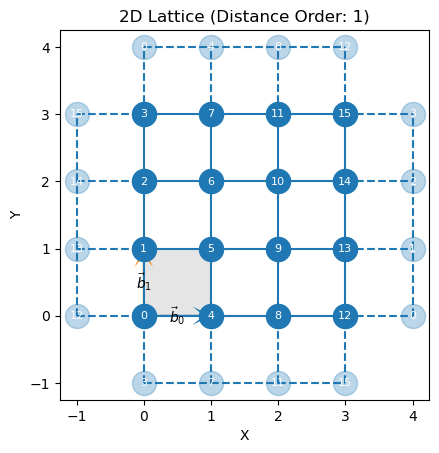

<Axes: title={'center': '2D Lattice (Distance Order: 1)'}, xlabel='X', ylabel='Y'>

In [4]:
lattice.draw()

In [7]:
[edge for edge in lattice.edges() if edge[0]==0]

[(0, 1), (0, 4), (0, 3), (0, 12), (0, 5), (0, 7), (0, 13), (0, 15)]

In [ ]:
options = ocp.CheckpointManagerOptions(
    max_to_keep=None,
    create=False,   # MUY IMPORTANTE: no crear si no existe
)

handler = ocp.PyTreeCheckpointHandler()
checkpointer = ocp.Checkpointer(handler)

manager = ocp.CheckpointManager(
    "/home/ihuarte/Escritorio/Ivan/NNs/pruebas/J1J2Square/BeccaSplitTraining_Sequential_CvT_CMLP_Mean_Sum/Size_4x4/ST_5000-0-1/UUID_c2c74f65/J1J2Square_BeccaSplitTraining_simulation_4x4_J1J2_1.0_0.5_XYZ_0.0_0.0_0.0_date_20260224T174951_UUID_c2c74f65_checkpoint.orbax",
    checkpointer,
    options
)

manager.restore(500)
ocp.

/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:711: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


{'parameters': {'Seq_0': {'CvTWorker_0': {'StageBlock_0': {'ConvProjectionBlock_0': {'DepthPointwiseConv_0': {'Conv_0': {'kernel': Array([[[[ 0.12636633, -0.4970139 , -0.06385407, -0.11087977,
                  -0.57332665, -0.15471028,  0.22095877,  0.25468823,
                  -0.09083968, -0.06493051, -0.19375119, -0.3621968 ,
                   0.1750333 ,  0.36558053,  0.7175796 ,  0.22140276,
                  -0.5122214 ,  0.72131246, -0.08669188,  0.2183673 ,
                   0.26107392, -0.12394615,  0.45783263,  0.07592535,
                   0.323883  , -0.10269912, -0.22567095,  0.26575074,
                   0.3020588 ,  0.06177036,  0.4135574 , -0.30921367,
                  -0.46895254,  0.0941111 , -0.01977147, -0.32392037,
                   0.09904743, -0.6366235 , -0.30275074, -0.79009837,
                  -0.55062693, -0.22152749,  0.06314484,  0.02948751,
                   0.1590565 ,  0.46465716,  0.17554773,  0.34081346,
                   0.22675005, -0.173

(5, 10, 2)

In [ ]:

def c4_operation(lattice_size):
    def _operation(configuration):
        configuration = configuration.reshape(lattice_size).T[::-1]
        return configuration.reshape(-1)
    return _operation

class Cn():

    def __init__(self, lattice_size, n):
        """
        C_n rotation symmetry
        """

        self.lattice_size = lattice_size

        self.dim = 1
        self.N = 4
        self.character = lambda q, m: jnp.exp(2 * jnp.pi * q * m / n)

        assert self.N != 1, f"Group size too low. N = 1"
        assert all(L != 1 for L in self.lattice_size)

        if n == 4:
            self.operation = c4_operation(lattice_size)
        

    
class Refl_H():
    
    def __init__(self, lattice_size):
        """
        Reflection symmetry respect to the horizontal axis
        """

        self.lattice_size = lattice_size

        self.dim = 1
        self.N = 2
        self.character = lambda k, m: 1 if k==0 else (-1)**m

        assert self.N != 1, f"Group size too low. N = 1"
        assert all(L != 1 for L in self.lattice_size)

    def operation(self, configuration):
        return configuration.reshape(self.lattice_size)[::-1]
    
class Refl_V():
    
    def __init__(self, lattice_size):
        """
        Reflection symmetry respect to the horizontal axis
        """

        self.lattice_size = lattice_size

        self.dim = 1
        self.N = 2
        self.character = lambda k, m: 1 if k==0 else (-1)**m

        assert self.N != 1, f"Group size too low. N = 1"
        assert all(L != 1 for L in self.lattice_size)

    def operation(self, configuration):
        return configuration.reshape(self.lattice_size)[:, ::-1]

class Refl_D():
    
    def __init__(self, lattice_size):
        """
        Reflection symmetry respect to the horizontal axis
        """

        self.lattice_size = lattice_size

        self.dim = 1
        self.N = 2
        self.character = lambda k, m: 1 if k==0 else (-1)**m


        assert self.N != 1, f"Group size too low. N = 1"
        assert all(L != 1 for L in self.lattice_size)

    def operation(self, configuration):
        return configuration.reshape(self.lattice_size).T
    
class Refl_AD():
    
    def __init__(self, lattice_size):
        """
        Reflection symmetry respect to the horizontal axis
        """

        self.lattice_size = lattice_size

        self.dim = 1
        self.N = 2
        self.character = lambda k, m: 1 if k==0 else (-1)**m

        assert self.N != 1, f"Group size too low. N = 1"
        assert all(L != 1 for L in self.lattice_size)

    def operation(self, configuration):
        return configuration.reshape(self.lattice_size)[:, ::-1].T[:, ::-1]
    

In [56]:
size = (3,3)
N = jnp.prod(jnp.array(size))
x = jnp.arange(N)
sym = Refl_AD(size)
x.reshape(size)

Array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]], dtype=int64)

In [57]:
x_1 = sym.operation(x)
x_1

Array([[8, 5, 2],
       [7, 4, 1],
       [6, 3, 0]], dtype=int64)

In [40]:
x_2 = sym.operation(x_1)
x_2

Array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]], dtype=int64)

In [ ]:
x_3 = sym.operation(x_2)
x_3

Array([[12,  8,  4,  0],
       [13,  9,  5,  1],
       [14, 10,  6,  2],
       [15, 11,  7,  3]], dtype=int64)

In [ ]:
x_3 = sym.operation(x_3)
x_3

Array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]], dtype=int64)

In [58]:
        print(f"Subtype: {jnp.issubdtype(jnp.complex128, jnp.complexfloating)}")


Subtype: True


In [ ]:
import numpy as np
#oxalate
x_ED = np.loadtxt("/home/ihuarte/Escritorio/Ivan/NNs/new_pruebas/Oxalate/Factorized_CvT_Szabo_Transversal_Factorized/Size_4x4/ST_1000-A/UUID_4e71c27c/Oxalate_Factorized_CvT_Szabo_xED_4x4_strength_0.2_theta_9.0_phi_72.0.txt", dtype=complex)

# j1j2
# x_ED = np.loadtxt("/home/ihuarte/Escritorio/Ivan/NNs/new_pruebas/J1J2Square/Jastrow_Transversal_Jastrow_wrap/Size_4x4/ST_1500A/UUID_1b2e9d23/J1J2Square_Jastrow_xED_4x4_J1J2_1.0_0.5_XYZ_0.0_0.0_0.0.txt", dtype=complex)


In [ ]:
size = (4,3)
a =0.2
theta = 9.0
phi = 72.0
cm_model = Oxalate(size, [a, theta, phi], order="default_2", bc='periodic')

eng = Runner(cm_model.cm, S_operators=True)
E_ED, x_ED = eng.exact_energy_lanczos(k=1, eigenstates=True)
x_ED=x_ED.flatten()

In [ ]:
E_ED

In [ ]:
mod = jnp.abs(x_ED)
phase = jnp.angle(x_ED)

no_null_mod_mask = mod > 1e-12
phase_mask = phase[no_null_mod_mask]

counts, values = jnp.histogram(phase, bins=1000000)
counts_mask, values_mask = jnp.histogram(phase_mask, bins=1000000)

weights = mod
counts_weighted, values_weighted = jnp.histogram(phase_mask, bins=1000000, weights=weights)


In [ ]:
kde = sp.stats.gaussian_kde(phase, bw_method=0.01, weights=weights/jnp.sum(weights))

In [ ]:
_, ax = plt.subplots(figsize=(15,6))
ax.set_title("Phase distribution KDE size " + f"{size[0]}x{size[1]}", fontsize=20)
ax.plot(jnp.linspace(-jnp.pi, jnp.pi, 1000), kde.evaluate(jnp.linspace(-jnp.pi, jnp.pi, 1000))[::-1], label="KDE with weights", color="blue")

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 1,  figsize=[20, 10])
fig.suptitle("J1-J2 Model  (J2/J1 = 0.5)", fontsize=30)
fig.suptitle("Oxalate  (QSL)", fontsize=30)
ax[0].set_title("Phase histogram")
ax[1].set_title("Phase histogram with no null modulus")
ax[2].set_title("Phase histogram weighted by modulus squared")
ax[0].hist(
    phase,
    bins=1000,
    range=(-np.pi, np.pi),
    density=True,
    alpha=0.7,
    label=f"ED",
)
ax[1].hist(
    phase_mask,
    bins=1000,
    range=(-np.pi, np.pi),
    density=True,
    alpha=0.7,
    label=f"ED",
)
ax[2].hist(
    phase,
    bins=1000,
    range=(-np.pi, np.pi),
    weights=weights,
    density=True,
    alpha=0.7,
    label=f"ED",
)

ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[2].set_yscale('log')
ax[0].set_ylim(1e-2, 1e2)
ax[1].set_ylim(1e-2, 1e2)
ax[2].set_ylim(1e-2, 1e2)

In [ ]:
from NN_module.observables import all_spin_configurations

In [ ]:
def print_max_contributors(x, size, N_max=10, return_states=False):
    (mod, ph), _ = modphase(x)
    configs = all_spin_configurations(size[0] * size[1])

    idx = jnp.argsort(mod)[::-1][:N_max]
    max_configs = configs[idx, :]
    max_mods = mod[idx]
    max_phs = ph[idx]

    for config, mod, phs in zip(max_configs, max_mods, max_phs):
        tmagn = jnp.sum(config.flatten())
        print(f"Config: \n{config.reshape(size)}")
        print(f"M = {tmagn}")
        print(f"\nModulus: {mod}")
        print(f"Phase: {phs}\n")

    if return_states:
        return max_configs

In [ ]:
size = (4,4)
mod = jnp.abs(x_ED)
phase = jnp.angle(x_ED)
configs = all_spin_configurations(size[0] * size[1])

max_contr_idx = jnp.argsort(mod)[::-1]
sorted_modulus = mod[max_contr_idx]
sorted_configs = configs[max_contr_idx, :]

config_magnetization = jnp.sum(sorted_configs, axis=-1)/2



In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1,  figsize=[20, 10])

fig.suptitle("J1-J2 Model  (J2/J1 = 0.5)", fontsize=30)
fig.suptitle("Oxalate  (QSL)", fontsize=30)

ax[0].set_title("Magnetization histogram (raw histogram)")
ax[1].set_title("Magnetization histogram (weighted by modulus)")
ax[0].hist(
    config_magnetization,
    bins=33,
    range=(-16, 16),
    density=True,
    alpha=0.7,
    label=f"ED",
    edgecolor='black',

)
ax[1].hist(
    config_magnetization,
    bins=33,
    range=(-16, 16),
    weights=sorted_modulus,
    density=True,
    alpha=0.7,
    label=f"ED",
    edgecolor='black',
    
)

ax[0].set_xticks(jnp.arange(-16,18,2))
ax[1].set_xticks(jnp.arange(-16,18,2))
# ax[0].set_yscale('log')
# ax[1].set_yscale('log')
# ax[0].set_ylim(1e-2, 1e2)
# ax[1].set_ylim(1e-2, 1e2)

In [ ]:
max(mod), min(mod)

In [ ]:
tramos = jnp.logspace(-6, 0, 100)
perc_under_x = []

for x in tramos:
    perc_under_x.append((sorted_modulus < x).sum()/sorted_modulus.shape[0] * 100)

    
_, ax = plt.subplots(figsize=(10,6))
ax.plot(tramos, perc_under_x)
ax.set_title("Percentage of total components under modulus ", fontsize=20)
ax.set_xlabel("Modulus", fontsize=15)
ax.set_ylabel("Percentage", fontsize=15)
ax.set_xscale('log')

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import scipy as sp
from VA_project.model.model import J1J2Square, Oxalate
from VA_project.engine.runners import Runner

size = (4,3)
a =0.2
theta = 9.0
phi = 72.0

for size in [(2,2), (2,3), (3,3), (4,3), (4,4), (4,5)]:
    cm_model = Oxalate(size, [a, theta, phi], order="default_2", bc='periodic')

    eng = Runner(cm_model.cm, S_operators=True)
    E_ED, x_ED = eng.exact_energy_lanczos(k=1, eigenstates=True)
    x_ED=x_ED.flatten()
    mod = jnp.abs(x_ED)
    phase = jnp.angle(x_ED)
    weights = mod
    kde = sp.stats.gaussian_kde(phase, bw_method=0.01, weights=weights/jnp.sum(weights))

    _, ax = plt.subplots(figsize=(15,6))
    ax.set_title("Phase distribution KDE size " + f"{size[0]}x{size[1]}", fontsize=20)
    ax.plot(jnp.linspace(-jnp.pi, jnp.pi, 1000), kde.evaluate(jnp.linspace(-jnp.pi, jnp.pi, 1000))[::-1], label="KDE with weights", color="blue")
    plt.show()
    plt.close()

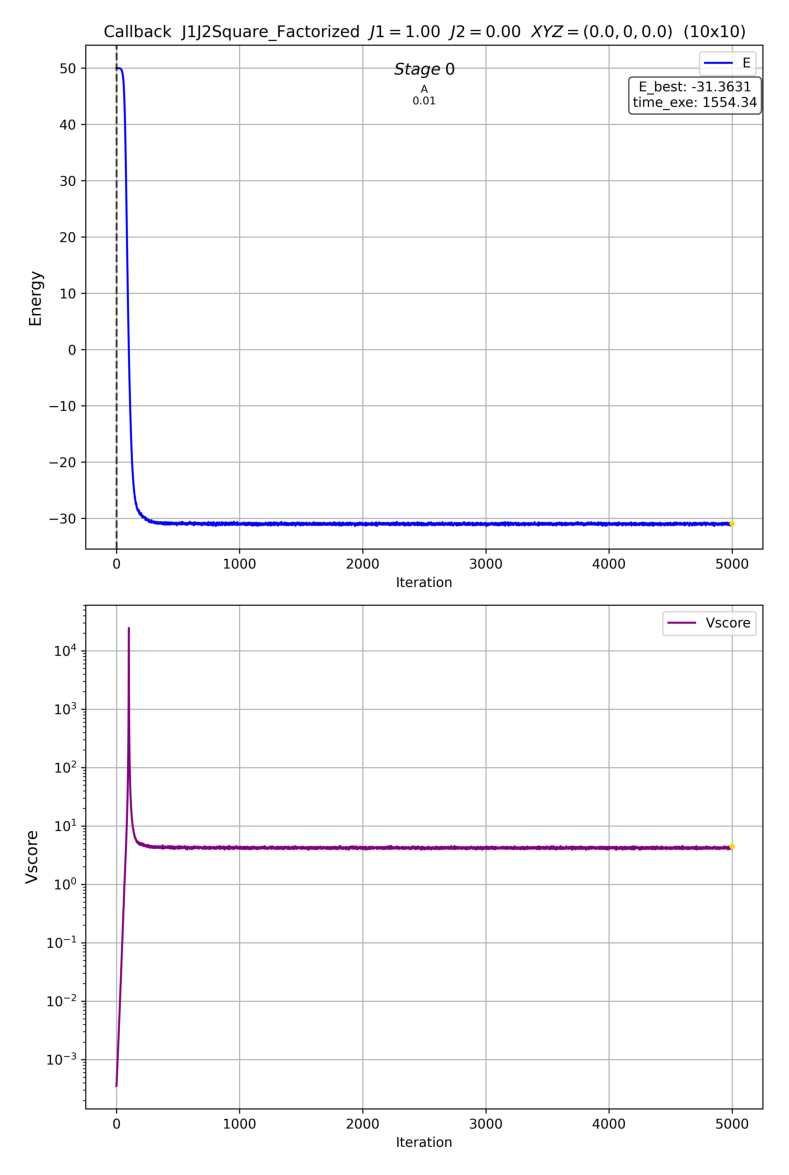

/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:711: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(




File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_a6d872cd/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260212T214902_UUID_a6d872cd.json
{'Trans_0': {'phi': Array([-6.03014813,  6.01114041, -6.10338032,  6.10374807, -5.91694506,
       -5.91945216,  6.09042619, -6.08651917,  5.81089325,  6.77057951,
        5.98375357, -7.5047649 ,  5.75360072, -5.91899598,  5.85907262,
        5.80200937, -6.1369988 ,  6.12865319, -5.842656  , -6.01678153,
       -7.61636747,  2.40849169,  7.42731135, -5.85287865,  5.82386713,
       -6.17506259,  6.08694071, -5.76401902,  6.1713773 ,  5.64626497,
       -4.53960157,  7.56296364, -5.98876078,  6.09302196, -6.11277889,
        6.13479691,  5.08361603, -6.26007987,  5.70536674, -6.32856443,
        6.94364518, -5.92303012,  6.10550057, -6.08026195,  6.21363019,
       -5.74856408, -6.12710879,  5.67064105, -7.00793209,  5.60666783,
       -3.85506292, 

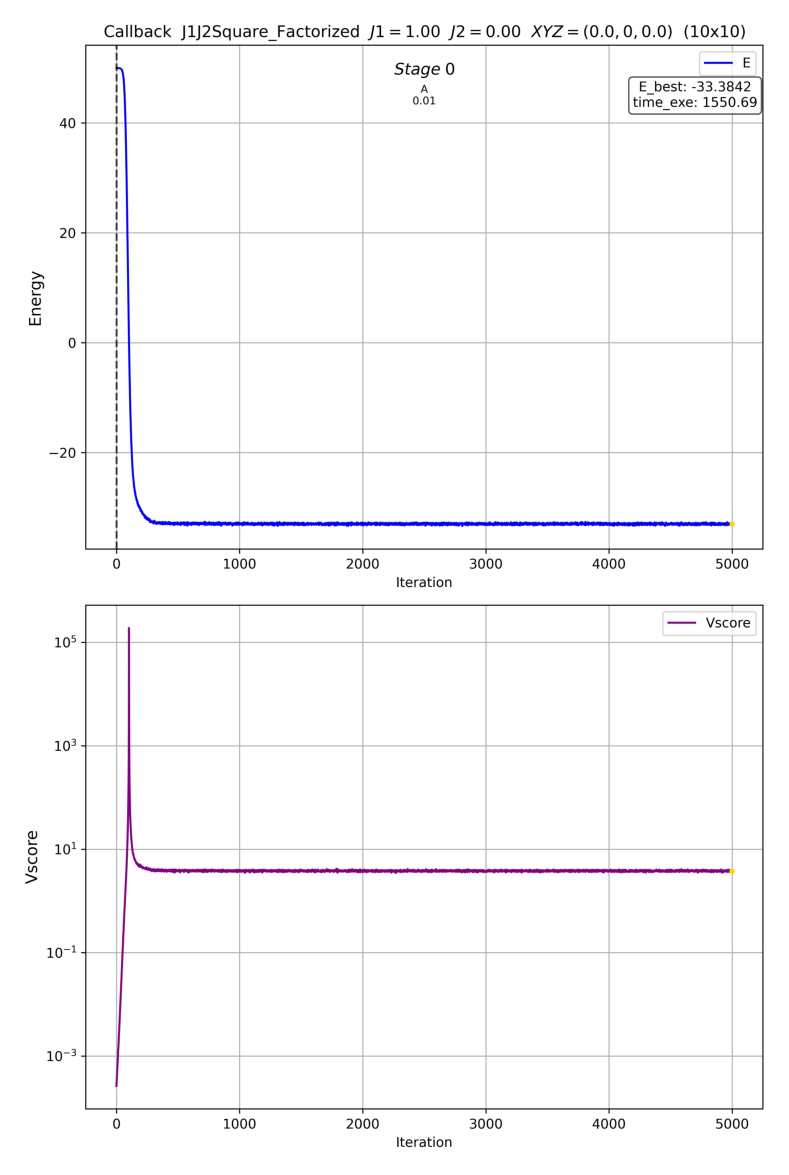



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_ca7f7651/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T045637_UUID_ca7f7651.json
{'Trans_0': {'phi': Array([-6.04138259,  6.48188763,  4.3461347 , -6.78676356,  5.72165343,
        6.00846628, -6.22028499,  5.79935728, -6.31846964,  6.01224868,
        6.11250186, -5.69244675, -6.83177056,  5.91153349, -6.53608388,
        4.72355765,  5.96131561, -8.26428684,  5.9307425 , -6.11143723,
       -6.09596579,  6.36722326,  4.55650413, -6.81544237,  5.92159613,
       -6.45518361,  8.23502987,  0.44048044, -8.25551222,  5.84885118,
        6.01820309, -6.04722292,  6.55439508,  4.42227488, -6.61111138,
        5.99070989, -5.95681796,  8.26392185, -5.79568543,  5.42037603,
       -5.82891918,  6.10824331, -6.01716467,  6.42085144,  5.7343096 ,
       -6.17812788,  6.07533229, -6.0175241 ,  6.09551406, -6.07906673,
        5.94375408, 

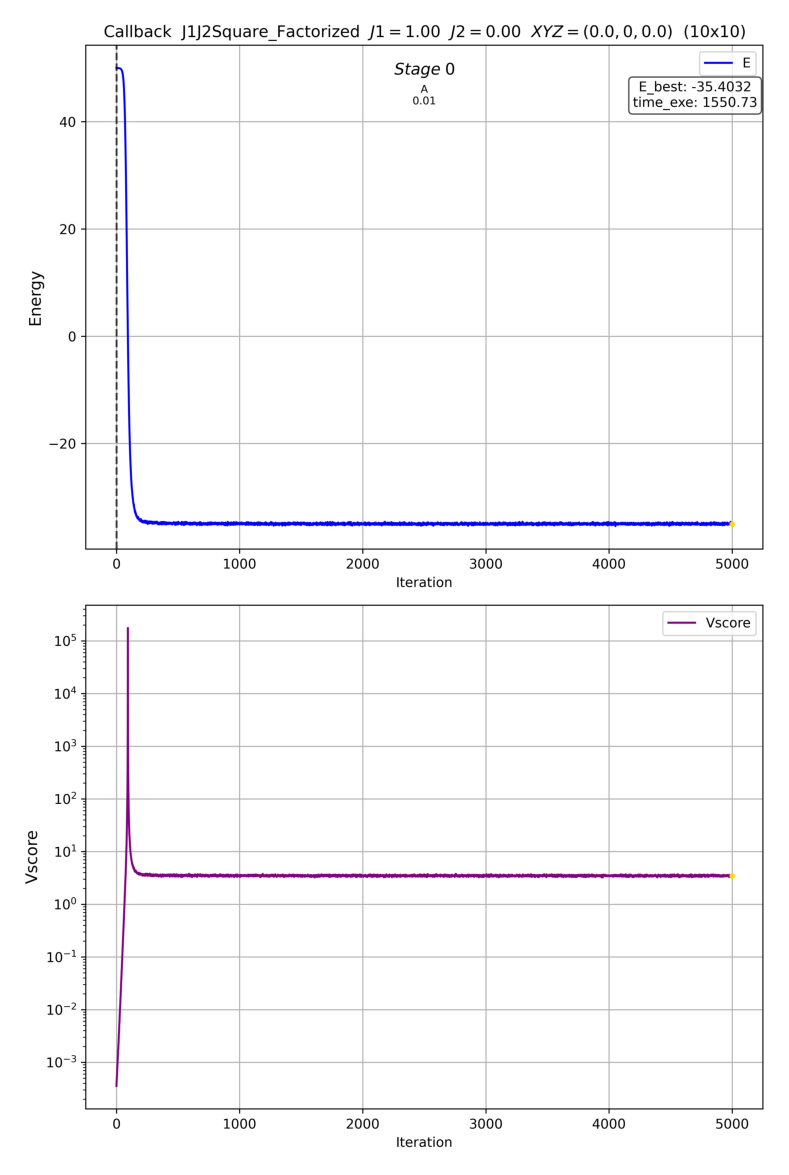



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_0519b981/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T040311_UUID_0519b981.json
{'Trans_0': {'phi': Array([-5.88402944,  6.05120919, -6.1547416 ,  5.89387845, -8.54396761,
       -5.59633167,  6.13792191, -6.07791936,  5.99991392, -7.39035645,
        7.49886264, -6.14565644,  5.73885   , -8.21684353, -0.54786729,
        8.23629395, -5.99803086,  6.03366915, -7.49877645, -2.48449216,
       -6.04109357,  5.84921965,  5.79196909, -5.71276199,  8.23249726,
       -5.92542361,  6.09385272, -6.09496859,  5.75662264,  7.46738973,
        6.1599233 , -5.81979198, -6.21197123,  6.07972632, -6.01383735,
        6.09708418, -6.06581353,  6.12226467, -5.90034898, -5.82791375,
       -6.06615573,  6.09090865,  5.28798301, -6.2337964 ,  6.06815145,
       -6.06644048,  6.06386939, -6.09828795,  5.86870879,  5.97918144,
        6.10628823, 

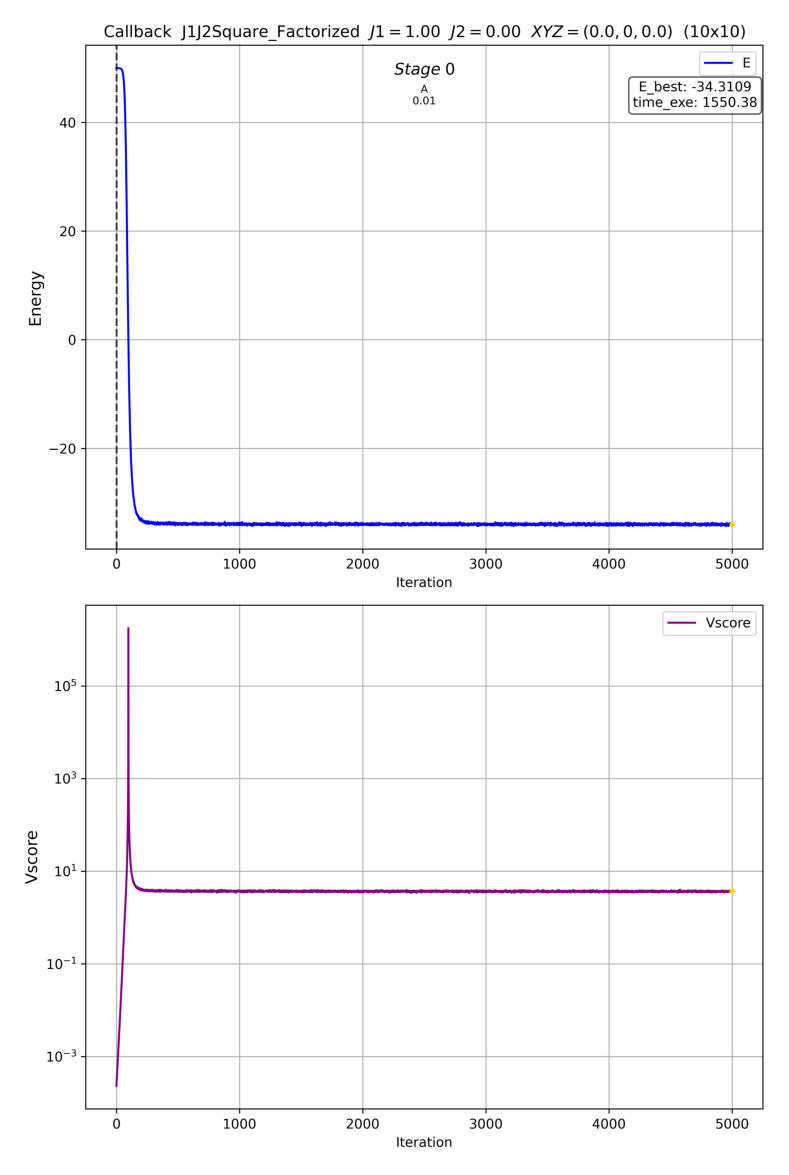



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_5454f7d2/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T021621_UUID_5454f7d2.json
{'Trans_0': {'phi': Array([-6.00677677,  6.08579587, -6.06150095,  6.14612941, -6.00016319,
        6.09047836, -6.09017259,  6.01677774, -6.12712554,  6.10747161,
        8.22724694, -5.93307885,  6.10092167, -6.05971175,  6.07199476,
       -6.08959457,  5.95075722, -7.57141092,  5.65102304, -5.74276095,
       -0.57138481,  8.82571699, -5.93523939,  6.08559698, -6.07027029,
        5.99041622, -7.7848287 , -2.2632957 ,  7.56822356, -8.19478734,
       -8.82244302, -0.91382203,  8.15552601, -5.9964469 ,  6.10249476,
       -6.88167592, -3.47910713,  7.83445681, -5.9499496 ,  5.96021745,
        5.9830378 , -8.11717548, -4.97343887,  6.14832375, -5.79146214,
       -4.92315577,  7.02356456, -5.94477505,  6.11147589, -6.02593905,
       -5.67614812, 

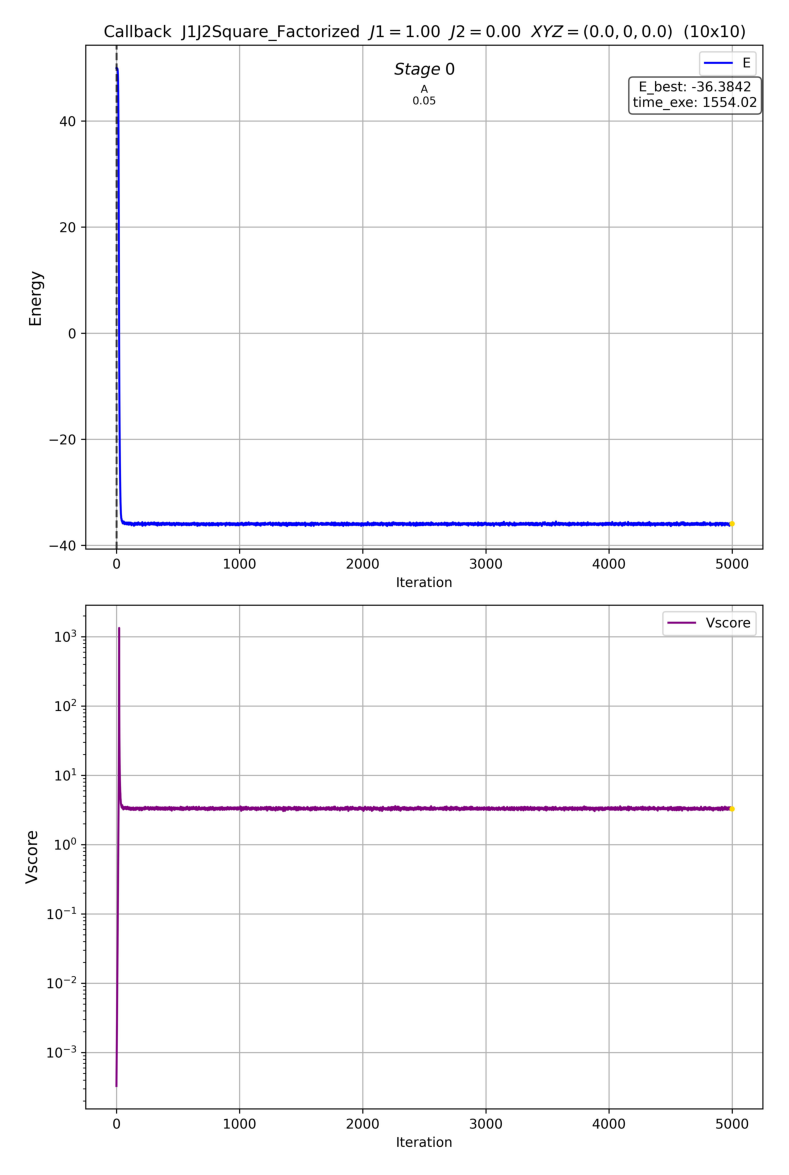



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_0c566b50/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260212T205529_UUID_0c566b50.json
{'Trans_0': {'phi': Array([-6.33857936, -7.26084137,  6.82897006, -6.84697894,  7.84532469,
       -9.66133514,  0.95347318,  9.67748607, -6.90596254,  6.66398459,
        7.32452036,  5.44728571, -7.3709245 ,  6.41776332, -9.73354314,
        6.60288005, -9.680869  , -6.47385521,  6.93635708, -6.87543173,
       -6.83417509,  7.28274149, -6.4652442 ,  9.74380396, -0.63364929,
       -9.76749617,  6.4886702 ,  6.80427145, -6.89367813,  6.89709558,
        6.90277184, -6.85302823,  6.96659173, -6.75300525,  9.76143814,
        5.1871566 , -7.16964164, -6.63877085,  6.93351441, -6.89726897,
       -6.89574107,  6.8771368 , -6.90373593,  6.90706681, -6.80025468,
        7.17854299, -6.57255923,  6.97539073, -6.86999485,  6.89844548,
        6.90005679, 

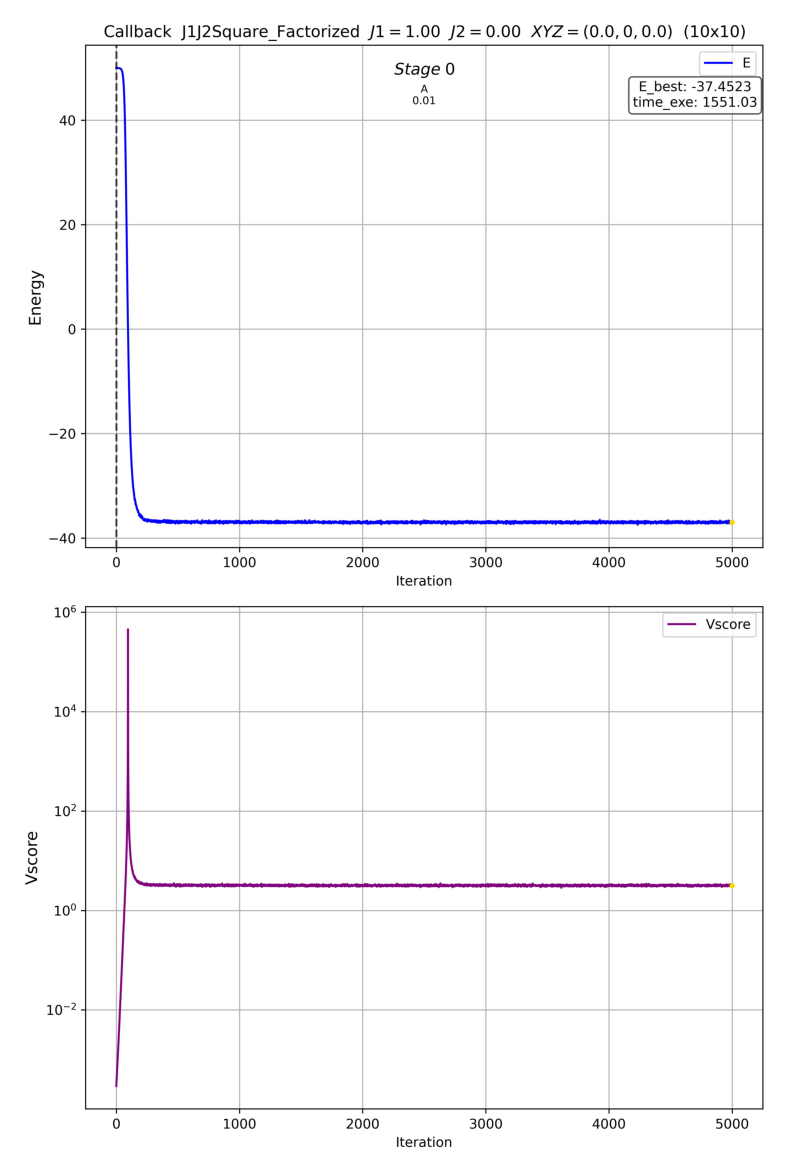



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_2bdbebfe/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260212T224234_UUID_2bdbebfe.json
{'Trans_0': {'phi': Array([ 5.72428413, -8.30021394,  0.07211089,  8.54536939, -6.0421162 ,
        5.70366352,  6.72281515, -3.78551672,  8.38875727, -5.88166037,
        5.9773808 , -5.65976831,  8.30459095, -5.92722807,  6.06735175,
       -6.22903142,  5.69208487, -6.75665795,  5.72760504, -5.85081611,
       -6.08952659,  6.12293904, -5.99096822,  6.09134865, -6.07482502,
        6.04306715, -6.12137621,  6.0289064 , -6.12966773,  6.14788006,
        6.06822988, -6.07620415,  6.07744804, -6.07207756,  6.07230573,
       -6.06453054,  6.07188479, -6.07902727,  6.07800455, -6.06179124,
       -6.09000215,  6.00824949, -6.1311636 ,  6.05840822, -6.07996439,
        6.09330625, -6.06205654,  6.0752346 , -6.06819287,  6.0760875 ,
        5.96686068, 

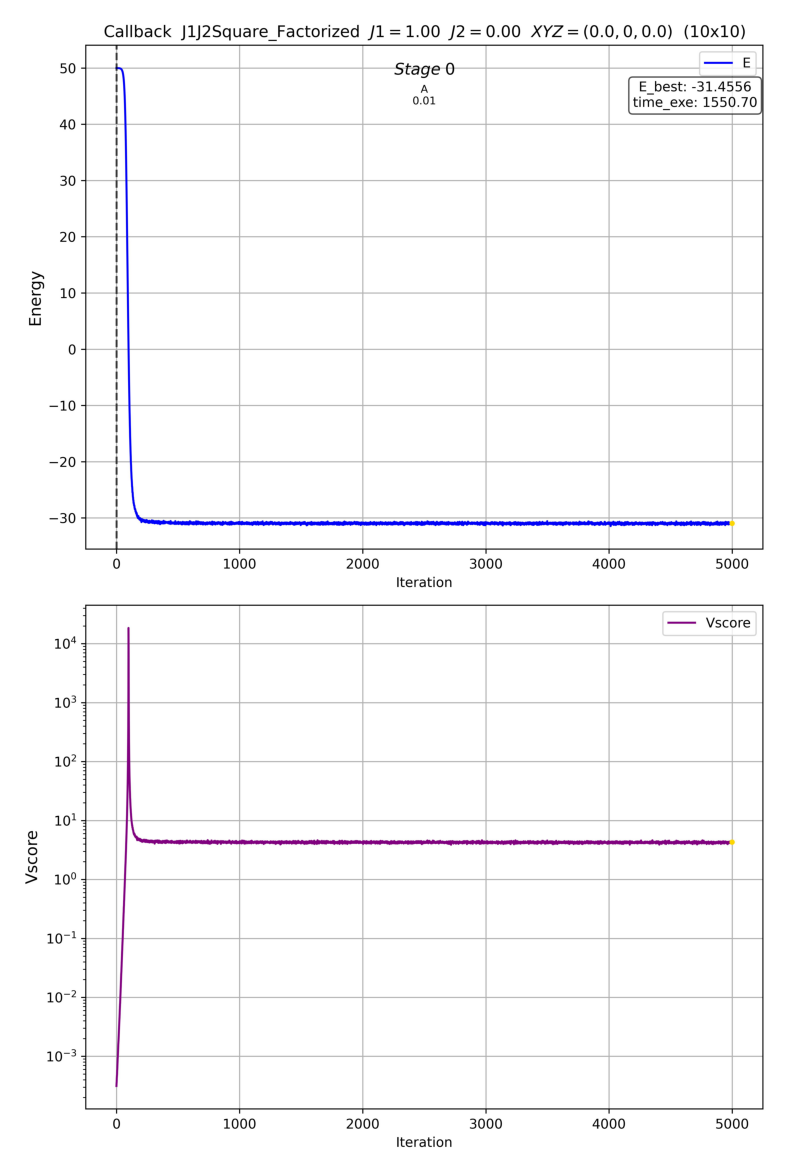



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_ebd4590a/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T033628_UUID_ebd4590a.json
{'Trans_0': {'phi': Array([ 6.06037873, -6.0336263 ,  6.01943234, -6.08212805,  6.06170736,
       -6.10687443,  5.76116844,  8.29771907, -0.13684806, -8.30849077,
       -6.13734724,  5.94606035, -8.12002586,  5.5731922 , -7.42331649,
        5.97530014, -5.98044761, -5.11990468,  8.31628835,  5.60809359,
        5.99446899, -8.11415359,  0.99288078,  8.45386613, -2.46174456,
       -8.52672898,  5.99894326, -6.00105616,  5.70273575, -6.19967372,
       -6.1297996 ,  5.61196868,  8.09451903, -5.87656705,  8.53670069,
        0.61098438, -8.22655559,  6.02485811, -6.15859124,  6.04028713,
        6.02056377, -6.55685975, -5.66456233,  6.15417286, -5.88898204,
        8.76081313,  5.61417649, -6.1133096 ,  6.08794608, -6.01351415,
       -6.45679335, 

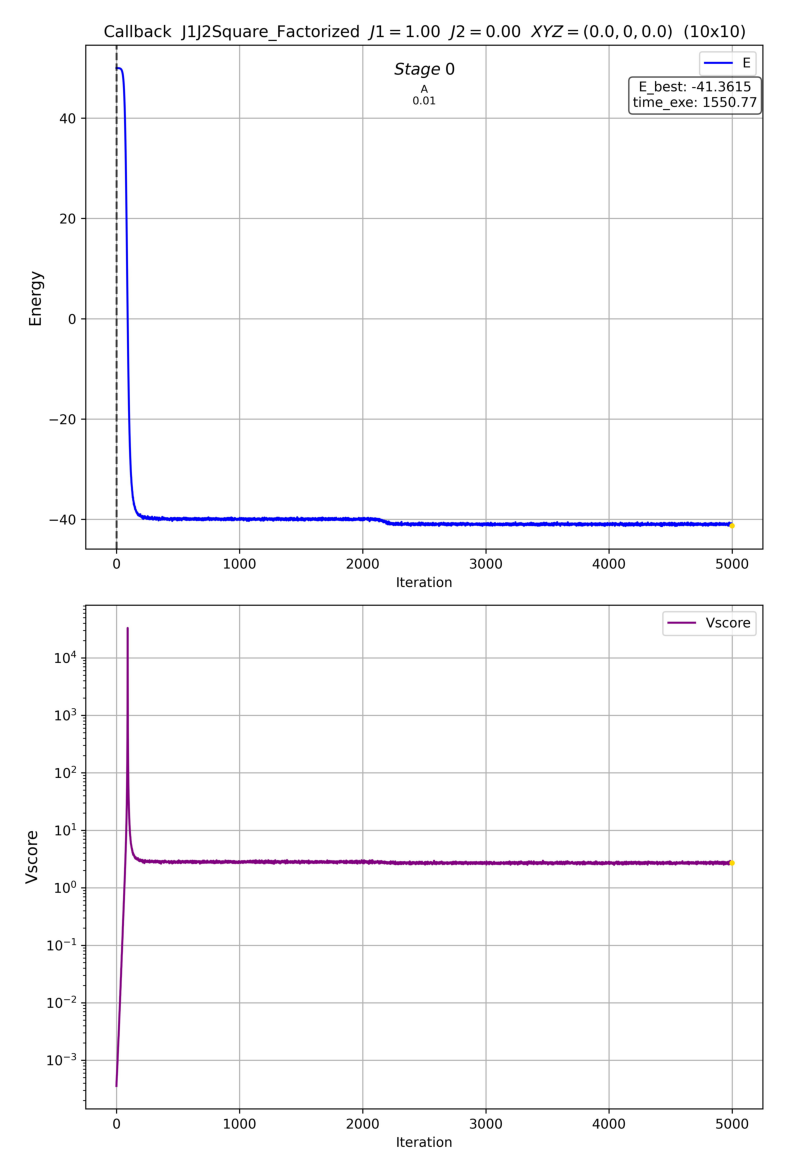



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_480fd62a/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T030945_UUID_480fd62a.json
{'Trans_0': {'phi': Array([ 5.8290304 , -6.15984435,  6.06044232, -6.08043919,  6.07698966,
       -6.06320194,  6.10421081, -5.96261885,  5.88232163, -5.9525155 ,
        5.71916175,  5.85806383, -6.12692979,  6.06729705, -6.0733171 ,
        6.09018322, -5.93229558, -5.56357417,  5.9743369 , -5.90127363,
       -6.50778031, -5.79507524,  6.0990275 , -6.08281026,  6.05913682,
       -6.0883656 ,  5.97763768,  5.48825706, -6.35802117,  6.0131697 ,
        4.43975533,  6.47030195, -6.0729065 ,  6.34762949, -6.10978463,
        6.05032456, -6.13136024,  5.79364101,  5.14181602, -6.63113322,
        6.46411049, -6.02020172,  6.39071811, -5.25134273,  6.37256649,
       -6.09392867,  6.05552872, -6.13606362,  6.07620634, -5.74131625,
       -6.04002445, 

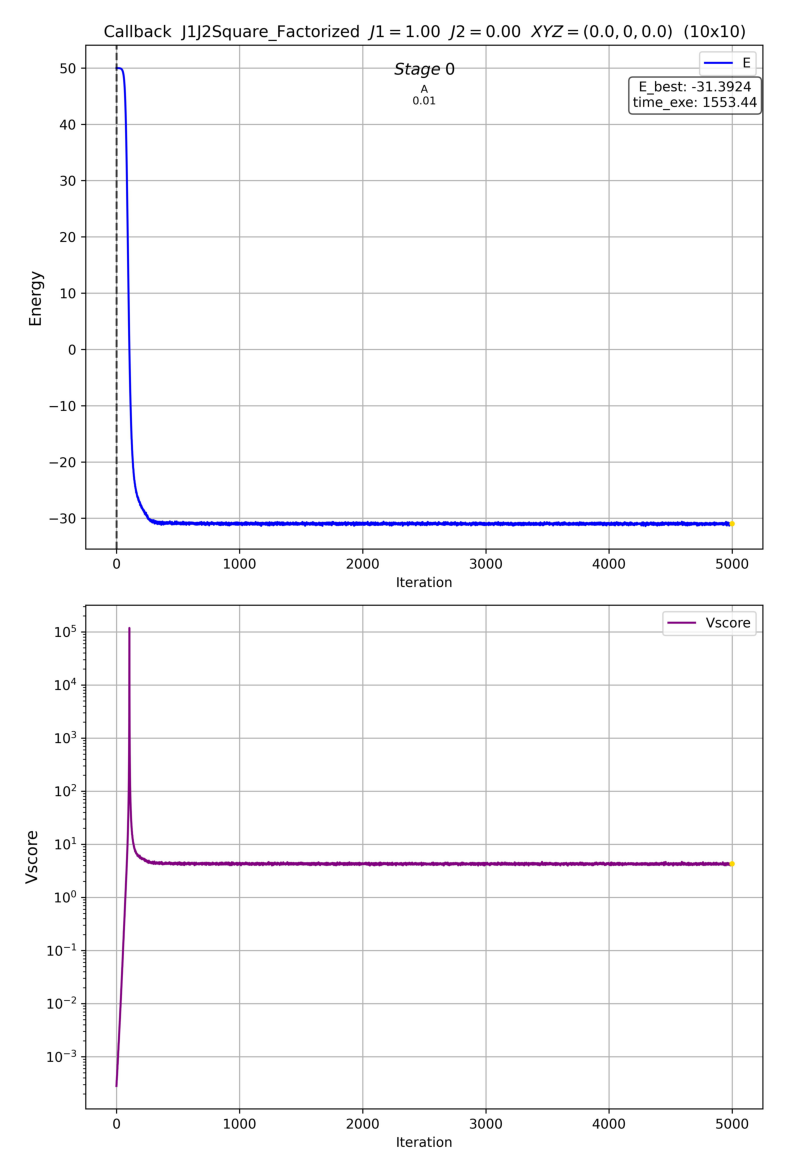



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_5626d14b/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T014938_UUID_5626d14b.json
{'Trans_0': {'phi': Array([-5.91437171e+00, -5.86732443e+00,  6.09596686e+00, -6.07817341e+00,
        5.94162728e+00, -7.99083274e+00,  5.71370406e+00, -5.87702040e+00,
        6.08271846e+00, -5.80809262e+00,  6.15571427e+00,  5.78546064e+00,
       -6.14776152e+00,  6.06784244e+00, -6.09618516e+00,  5.99033974e+00,
       -6.11905998e+00,  6.10939028e+00, -6.15962481e+00,  5.81302952e+00,
        5.71107009e+00, -6.13009931e+00,  6.16995247e+00, -5.99916459e+00,
        6.07621708e+00, -6.07948672e+00,  6.08073944e+00, -6.08113444e+00,
        6.04653771e+00, -6.23862147e+00, -6.02628292e+00,  8.31804989e+00,
       -5.53157135e+00,  8.10471682e+00, -5.94867217e+00,  6.07753839e+00,
       -6.08061611e+00,  6.01649630e+00, -5.79121526e+00,  7.9841

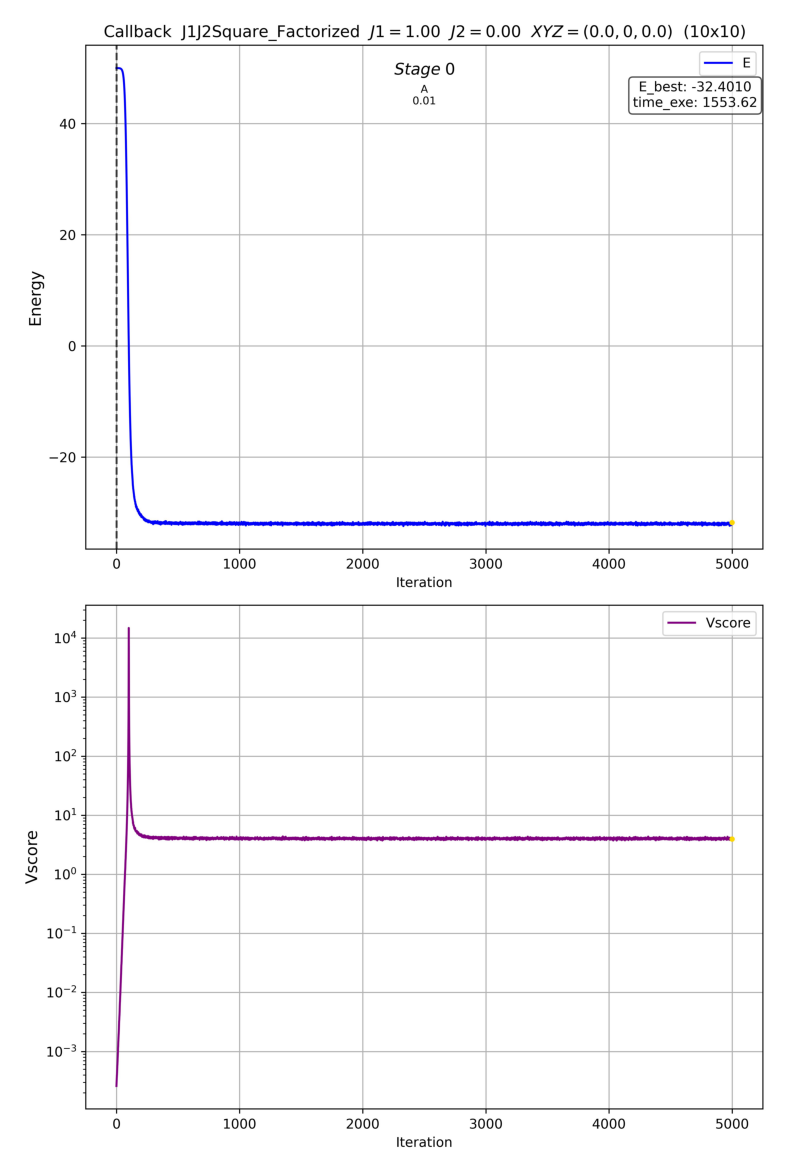



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_f50900ad/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260212T212215_UUID_f50900ad.json
{'Trans_0': {'phi': Array([-6.06648108,  6.07436375, -6.06709944,  6.05072356, -6.29203067,
       -4.58036885,  8.31777231, -0.35861502, -8.25795856,  6.02408378,
        6.12820186, -6.01620643,  6.06813365, -6.17543693,  5.7774432 ,
        6.40089084, -5.91058613,  8.24506307,  8.01519013, -5.98162959,
       -5.62480522,  7.67946699, -5.93495161,  6.1959047 , -5.80790587,
       -5.99851235,  6.02623364, -8.06865267,  1.07366459,  8.09027969,
       -7.679441  ,  1.84228346,  8.55595582, -5.97166696,  5.76793732,
        8.07931954, -5.94997636,  5.95142966, -8.09303383,  5.55944469,
        5.95190476, -8.57082777,  0.83382995,  8.1190028 , -8.05730852,
       -1.0196999 ,  8.12345214, -6.09242784,  5.91441245, -6.17874028,
       -6.07820261, 

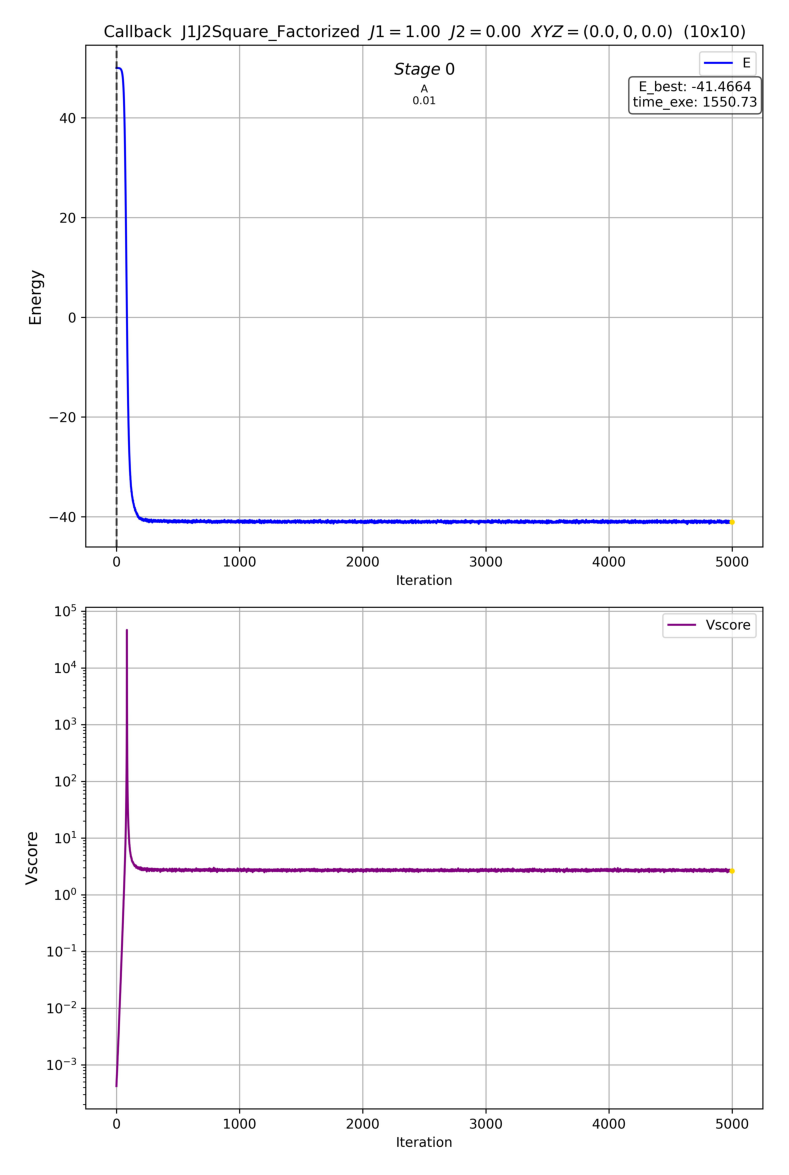



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_e6648a4b/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T055003_UUID_e6648a4b.json
{'Trans_0': {'phi': Array([ 1.27338582, -7.97626716,  6.09242823, -6.06043874,  6.07991245,
       -6.04140579,  6.45795207,  4.38327413, -6.46710218,  7.96095212,
       -7.99899739,  5.96013404, -6.0824315 ,  6.07689964, -6.0755458 ,
        6.07780947, -6.05104116,  6.38135509, -5.75993966,  5.73150367,
        6.00986803, -6.07852049,  6.07620617, -6.08049712,  6.08233668,
       -6.07807917,  6.07582259, -6.04675138,  6.16867505, -6.10693918,
       -6.07669122,  6.0645056 , -6.07348381,  6.07283956, -6.07089303,
        6.07877168, -6.06834823,  6.07888393, -6.05254227,  6.07369458,
        6.07356104, -6.07391014,  6.06538302, -6.07447589,  6.0769695 ,
       -6.07990903,  6.07041282, -6.08309499,  6.07999985, -6.07402689,
       -6.0074363 , 

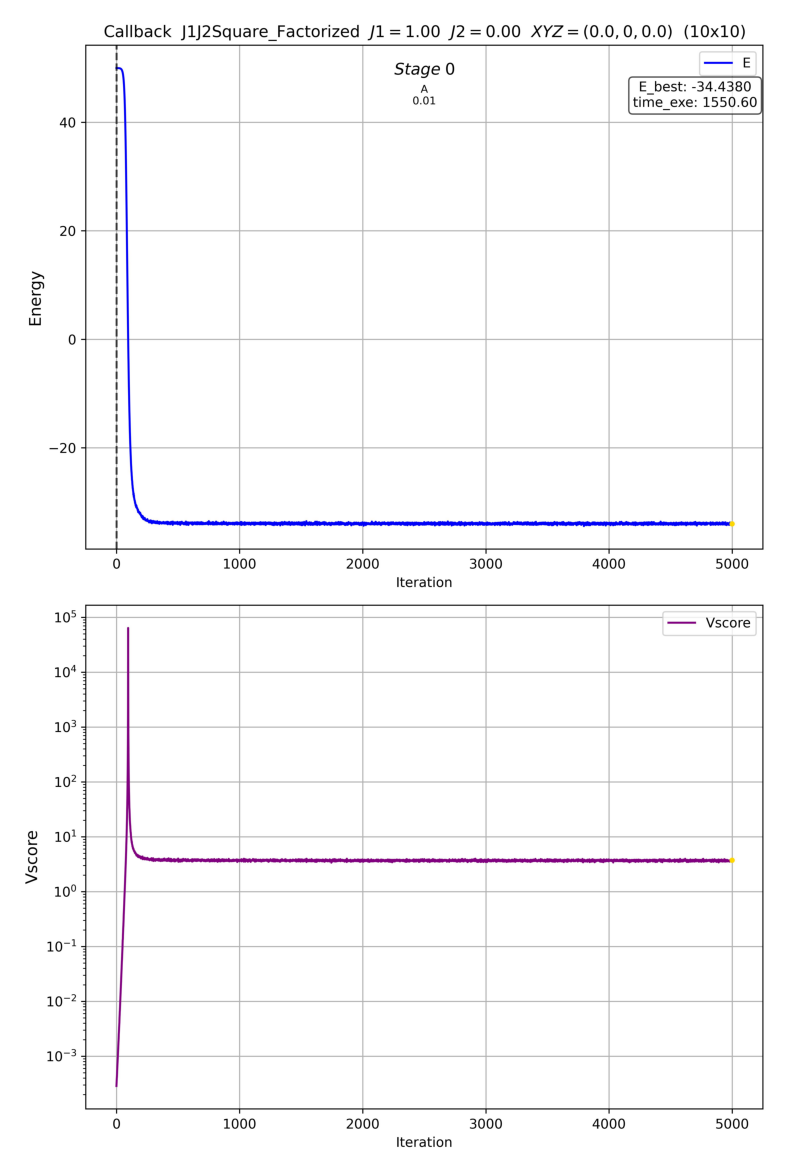



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_466c98f2/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T005610_UUID_466c98f2.json
{'Trans_0': {'phi': Array([-6.08709263,  6.09624462, -6.05618652,  6.09127195, -5.94942435,
        8.56288111,  0.81478222,  8.09171222, -8.21438988,  5.94296962,
        5.93140795, -6.0710703 ,  6.07076518, -6.0810162 ,  5.9787636 ,
       -8.0403054 , -8.12204085,  8.19288673, -0.6551957 , -8.88492379,
       -8.2515154 ,  6.00413303, -6.08483196,  5.9414368 , -8.74185931,
       -0.9501588 ,  8.09421308, -5.86280421,  8.88654578,  0.57021366,
        5.77435993, -6.11362627,  6.01630917, -8.17865099,  0.96861636,
        8.73942035, -5.93330743,  6.10006655, -5.9451068 ,  8.23139744,
       -5.78888531,  6.15466111, -6.46564601, -4.0002998 ,  8.18297639,
       -5.9415128 ,  6.08064593, -6.08859057,  6.05111192, -6.06081557,
        5.99293552, 

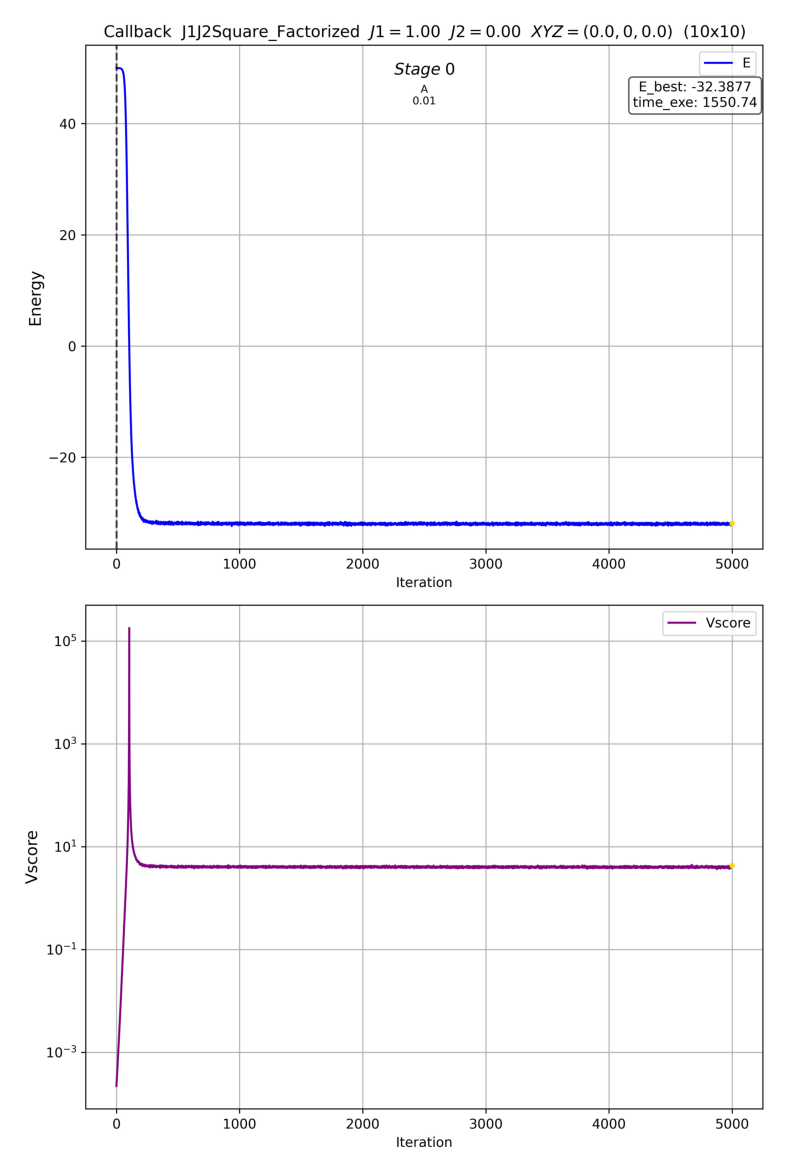



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_e89be6d7/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T002927_UUID_e89be6d7.json
{'Trans_0': {'phi': Array([-6.10682072,  6.11253526, -5.98236236,  8.10080715, -4.7173822 ,
       -6.13147523,  6.14364808, -5.7446536 , -7.98860162,  5.96562538,
        5.88098596, -5.7195651 ,  8.06926374,  1.07723316, -8.0681447 ,
        6.04108842, -6.05731598,  6.07256777,  5.0360686 , -6.15962736,
        5.78474634, -8.32626312,  4.37137125, -8.06146192,  8.28487054,
       -5.94764008,  6.08540818, -6.08982985,  6.03185477, -5.89226855,
       -8.30160093,  0.01343482,  8.30602476, -8.26982483,  0.07308794,
        8.60258745, -5.94739289,  5.98306222, -7.22293529,  5.66572447,
       -5.59858018,  8.30774491, -5.9497602 ,  5.95144316, -8.59950289,
       -2.48624155,  7.44222403, -7.18000198, -3.11994192,  7.22335715,
        6.13958304, 

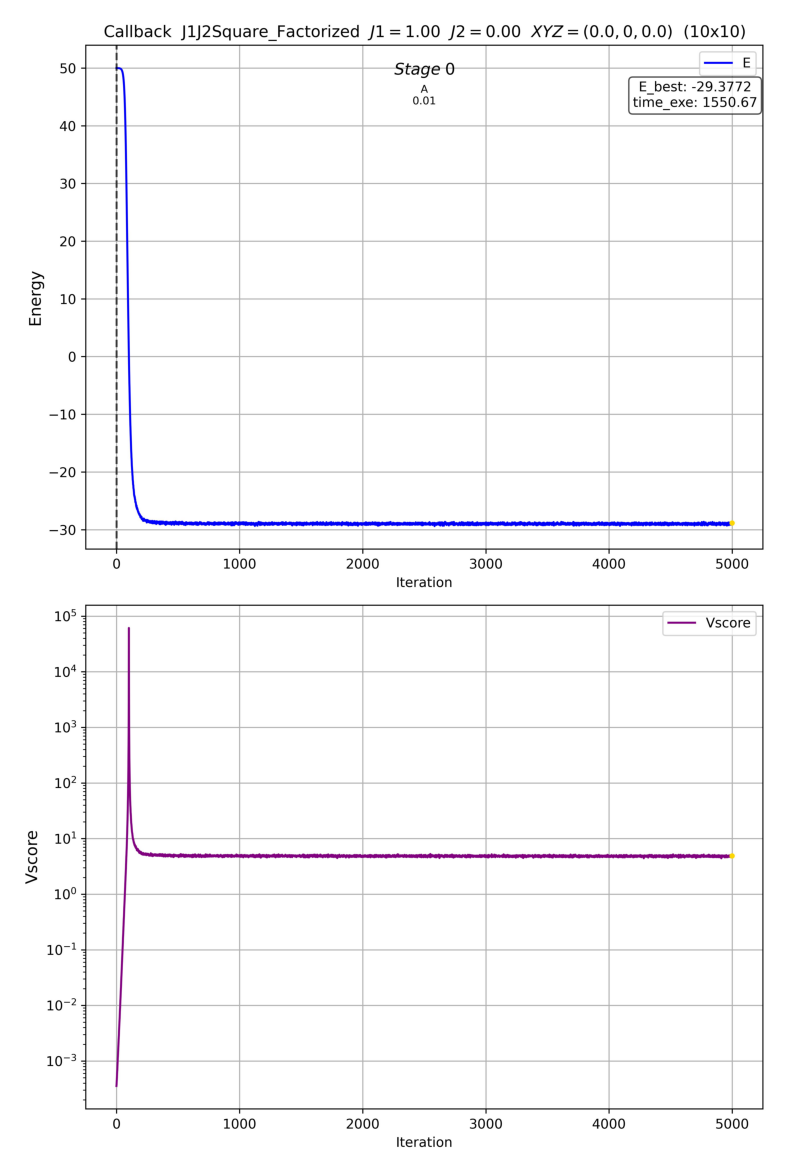



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_017fdc34/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T012252_UUID_017fdc34.json
{'Trans_0': {'phi': Array([-5.82285753,  5.84011713, -6.10171464,  8.36057844, -0.22161246,
       -9.08171743, -1.84403597,  8.56185999, -5.89696355,  6.24283439,
       -5.85562719,  5.84064341,  5.82943103, -5.96763698,  8.91034744,
        0.83135949,  9.04637812, -5.85308922,  6.19666777, -5.80238466,
        7.05142021, -5.93338886, -5.83029421,  6.59241591, -4.41975076,
       -8.8650878 , -0.68580794,  8.19273088, -6.05612375,  5.7446941 ,
       -3.45864955,  7.055913  ,  5.65642643, -7.96674132, -5.92743803,
        6.03427799, -8.15920233, -7.52375387,  5.91496795, -7.05478091,
       -7.04955425,  5.49106292, -8.70172072,  1.22254899,  7.94873968,
       -5.94505068,  7.60820484, -2.07184433, -7.59618962,  5.94015375,
        5.96463738, 

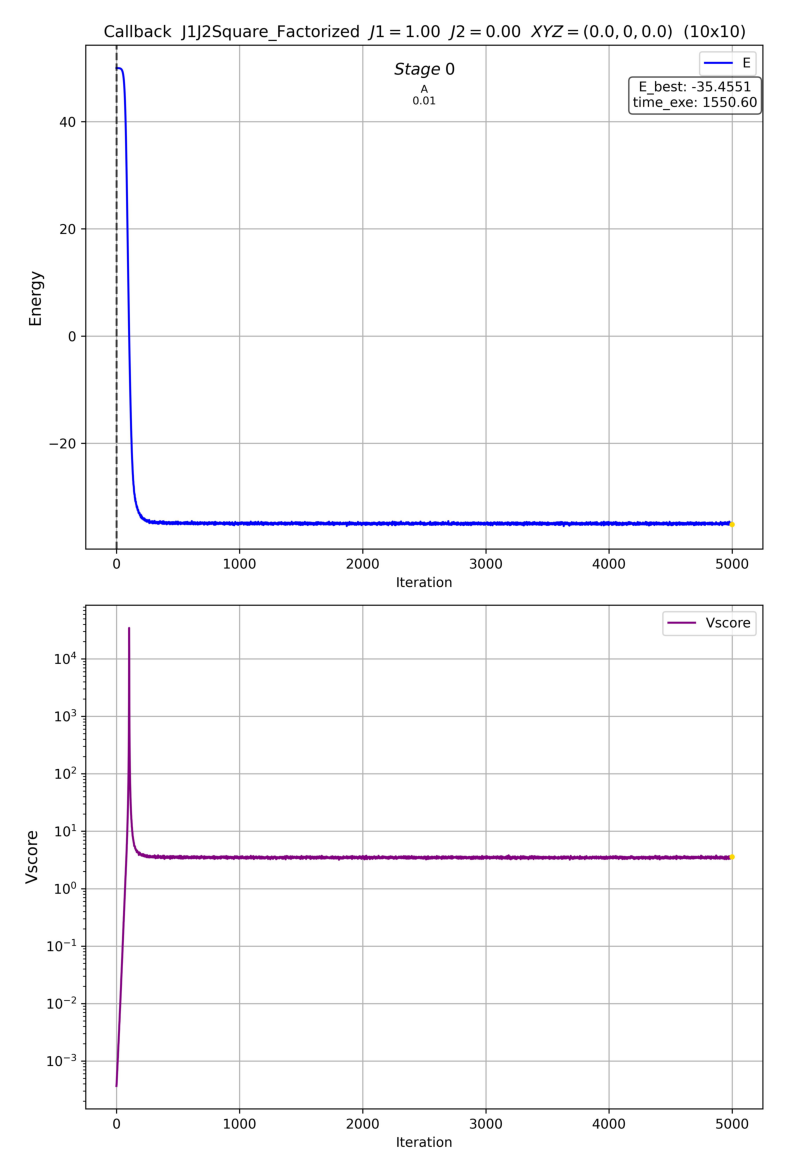



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_e652dd0d/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T052320_UUID_e652dd0d.json
{'Trans_0': {'phi': Array([-6.07768821,  6.0750856 , -6.00006905,  6.12725956, -6.10436552,
        6.12242092, -5.96910956,  6.13041108, -6.11271926,  6.03907406,
        6.08289201, -5.93743231,  8.23944162, -5.66309746,  5.91122133,
       -5.81016448,  6.64728661, -6.02082232,  6.0666422 , -6.08828592,
       -5.99925425,  8.23202252,  0.61881105, -8.23785512,  5.86277262,
       -6.39375995, -4.37967211,  6.45973008, -6.16430267,  6.0452911 ,
        6.11574627, -5.59288299, -8.70118042,  5.90186391, -6.08473622,
        6.02776001, -6.51021664,  5.83062553,  5.77505547, -6.14150501,
       -6.00085596,  7.90739195, -1.46697432, -7.91403111,  6.0026754 ,
       -6.09325152,  6.04067523, -6.03941919, -5.85749139,  6.10717655,
        6.10205922, 

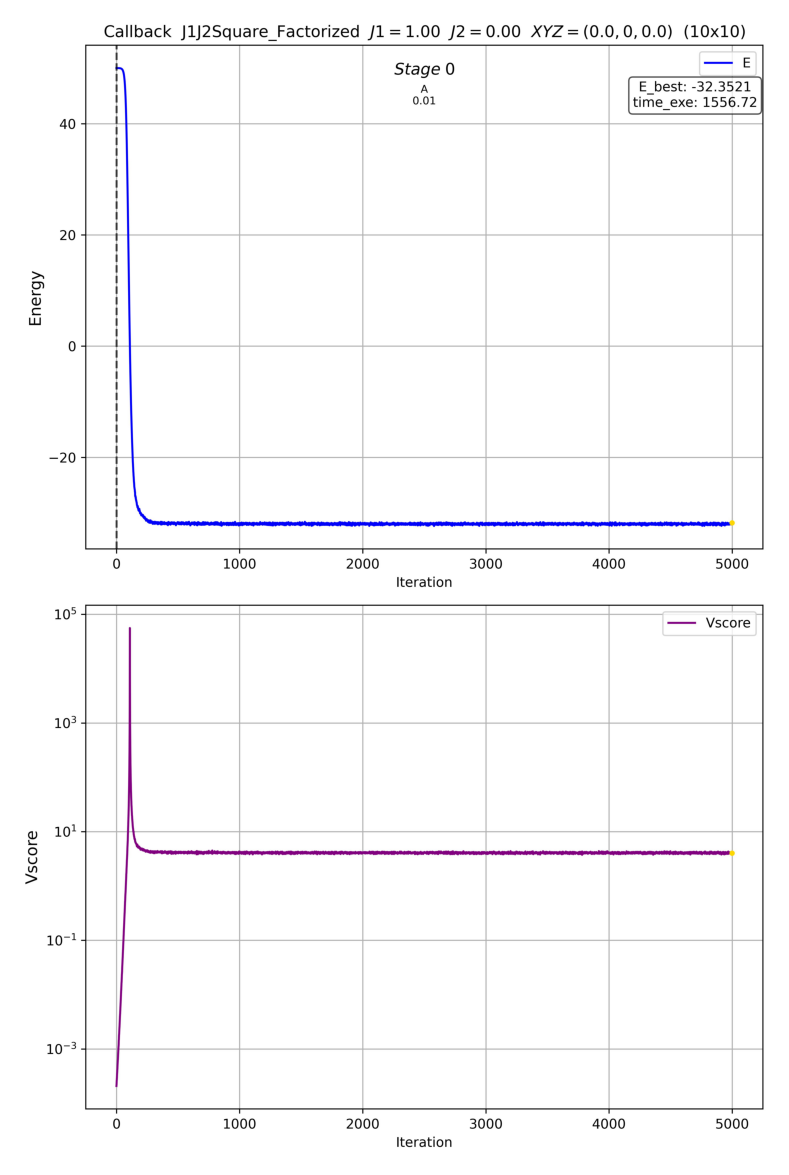



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_2b39a932/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260212T221550_UUID_2b39a932.json
{'Trans_0': {'phi': Array([ 6.13138051, -5.57950725, -8.79934674,  5.8677008 , -6.10825113,
        6.01013606, -6.49880237, -5.81872542,  6.02974756, -6.08945246,
       -6.01163836,  8.30330157, -0.07552379, -8.31649388,  5.96076847,
       -6.61268381,  4.33256585,  6.45726062, -6.03939146,  6.0766256 ,
        6.0915914 , -5.94582585,  8.31129103,  5.59875792, -6.2256014 ,
        5.56491023,  8.32824751, -5.9351605 ,  6.08177185, -6.07294948,
       -6.0584967 ,  6.10879784, -5.76229072, -6.20317812,  5.97167919,
       -8.27781956,  0.30201085,  8.85381647, -5.92398591,  6.08801621,
        6.03051164, -6.11766071,  6.13148089,  5.13921461, -6.30891824,
        5.89153374, -8.85470209,  0.82635918,  8.11035204, -6.01645072,
       -6.26530403, 

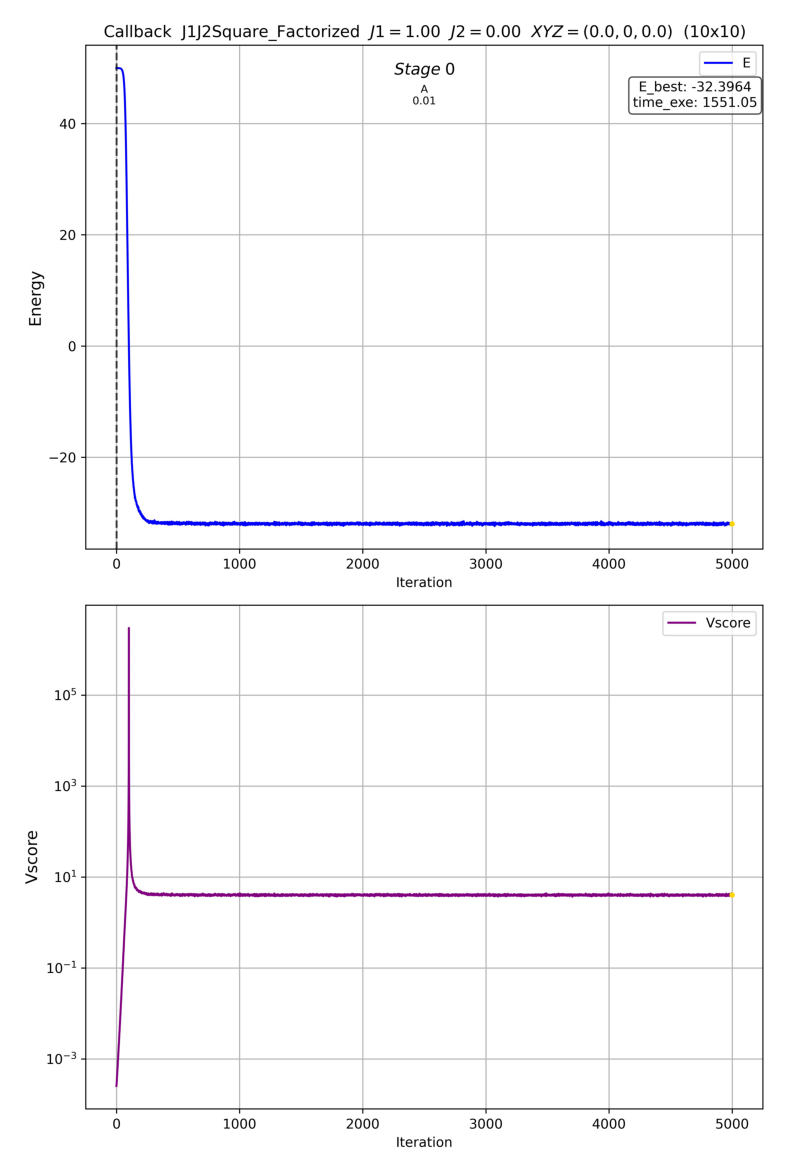



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_33b0486a/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260212T233602_UUID_33b0486a.json
{'Trans_0': {'phi': Array([-7.11934579, -5.69836031,  8.31931055,  0.47683677, -8.24880442,
       -5.58229185,  6.17042241, -6.19650764, -5.82527639,  6.01512059,
        5.85113342,  6.05010406, -4.47992924, -8.30795362,  5.64685161,
        6.44598919, -6.01748959,  5.9567462 ,  5.86882641, -6.13722133,
       -6.09061711,  5.88168752, -6.33445281,  5.96777719, -6.4431873 ,
       -4.48022369,  6.60597421, -5.77055735, -5.83896003,  6.10176335,
        6.05687906, -6.12616579,  5.99256067, -6.09017769,  6.02116397,
       -6.52159101,  5.71636814, -5.84024769,  6.22511182, -6.05794267,
       -6.31534445,  5.69271846, -6.99752961,  5.984601  , -6.08746999,
        6.03790576, -6.1881894 ,  6.1453641 , -6.04528528,  6.0316921 ,
        5.08280919, 

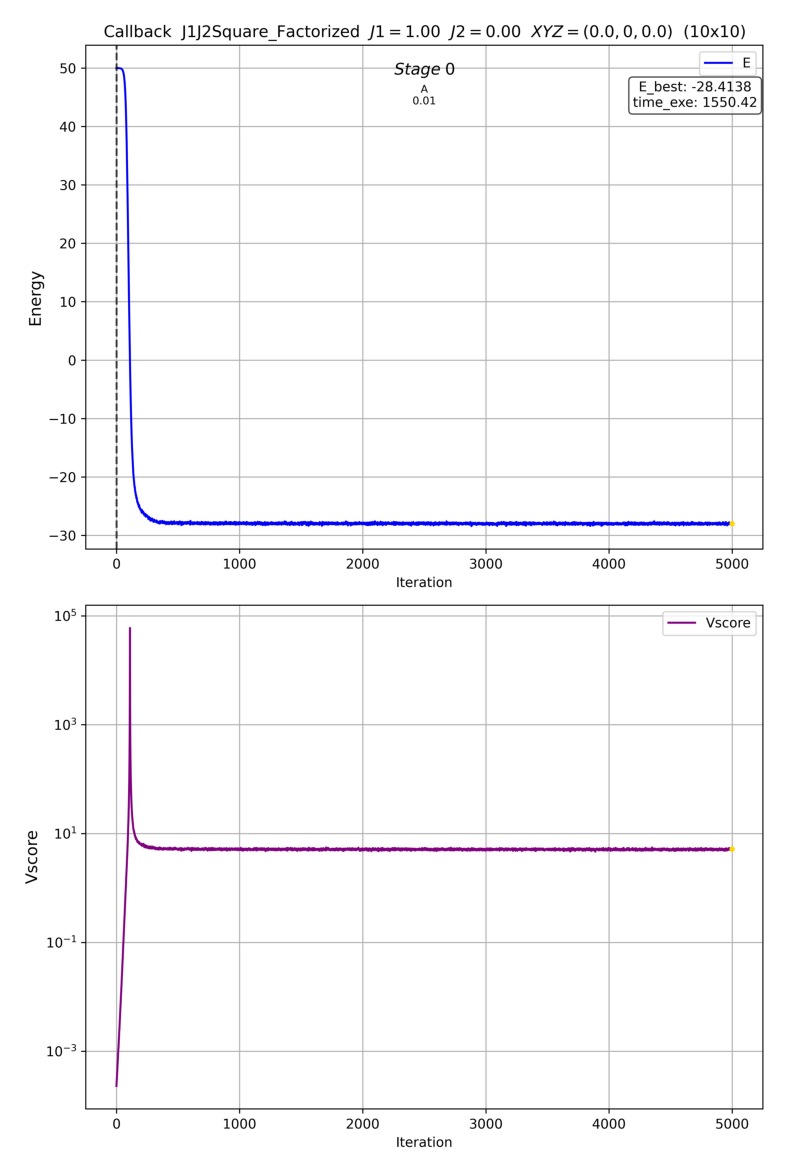



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_e13ade5b/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T000245_UUID_e13ade5b.json
{'Trans_0': {'phi': Array([ 6.02102621, -6.18199466,  5.73776044, -6.0010036 ,  5.47516593,
        5.98084189, -7.59638046, -8.25853036,  5.94410282, -6.15033172,
       -6.01407611,  6.07990559, -6.15312621,  6.01437257, -6.23429989,
       -4.88041331,  8.73727733, -0.17108218, -8.29571046,  5.70142686,
       -7.64438647, -5.86505935,  5.91668839, -8.22324529,  5.52974309,
       -7.79881346, -1.52038066,  9.1977919 , -5.53748622,  6.06656782,
        1.80836521,  7.7131333 , -8.80539805, -0.65232806,  8.20897705,
        5.70550526, -8.72779904,  0.20501819,  8.30443697, -7.75002027,
        7.73806962, -8.65516555, -0.83556828,  8.82037197, -5.76401249,
       -5.88304716,  5.99515217, -8.30424692,  5.67853464, -5.71820018,
       -8.74542554, 

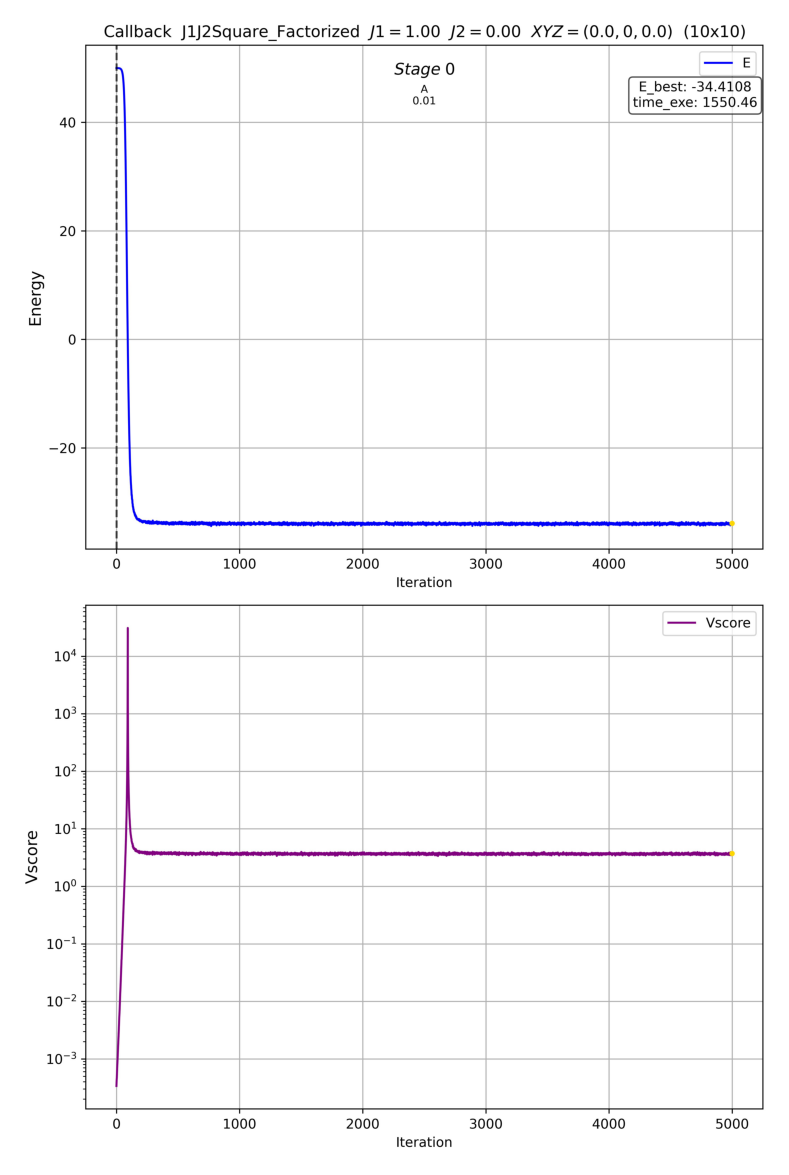



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_5d6aa25e/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T024303_UUID_5d6aa25e.json
{'Trans_0': {'phi': Array([-7.98770756,  5.95742367, -6.00225857,  6.0820323 , -6.12497632,
        5.66051041,  8.29489375, -5.92178374,  6.12377122, -5.69832502,
        5.80606613, -6.11921753,  6.08108205, -6.06799123,  6.0915145 ,
       -5.88792432, -5.78666062,  6.11053577, -6.07495882,  5.96200152,
       -5.92334562,  6.08212183, -6.0605128 ,  6.09240678, -5.95555992,
        8.09399914,  5.68892328, -6.11858837,  6.07887375, -5.91228341,
        5.79592396, -6.10714889,  6.06880699, -6.0008198 ,  8.1088318 ,
        0.94273886, -8.1202376 ,  6.01006963, -6.09761012,  5.96130753,
       -7.88597907,  5.9735548 , -5.99822101,  6.15655357, -5.57697072,
       -8.64332927,  5.86973442, -6.04126023,  6.1555676 , -5.66313989,
        1.48117369, 

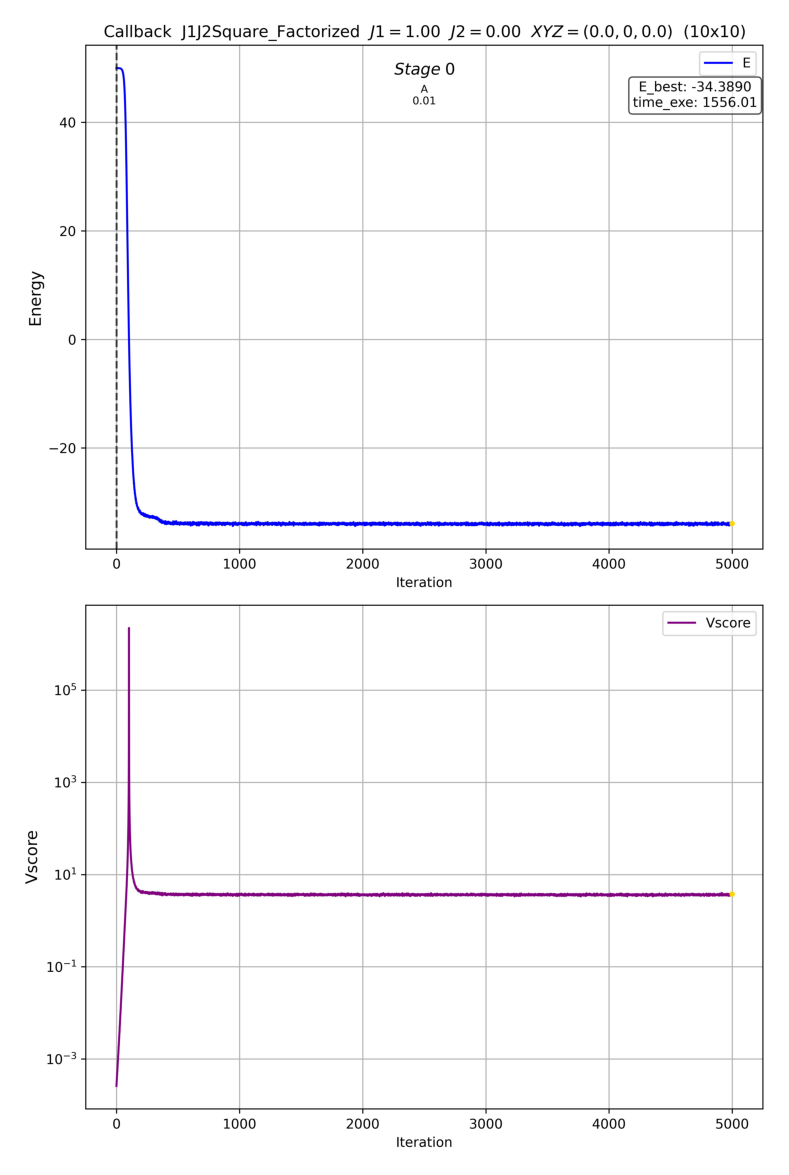



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_380d2601/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260212T202843_UUID_380d2601.json
{'Trans_0': {'phi': Array([-6.11378741,  6.04791075, -6.17931055,  6.0142043 , -6.11515751,
        5.86122828,  5.91279049, -5.98797719,  7.91289354,  5.71964285,
        6.0913694 , -6.2553686 ,  5.67531984, -6.3879906 ,  6.04555872,
       -5.95312486, -5.89697038,  5.98400335, -7.76477559, -5.71573097,
       -6.0709304 ,  5.76914931,  6.37892799,  5.68013276, -6.35539567,
        5.7562058 ,  5.91708605, -7.80343634,  1.74257496,  7.78215054,
        6.13787335, -5.87025665, -5.63125822, -5.80767082,  6.11701775,
       -7.97717767, -5.72436397,  5.6357836 ,  8.69446288, -5.87250796,
       -5.982776  ,  6.13654138, -5.81382612,  6.29529896, -7.97686111,
       -1.23126265,  7.97960845, -8.27255628, -0.33259056,  8.28689782,
        6.16391414, 

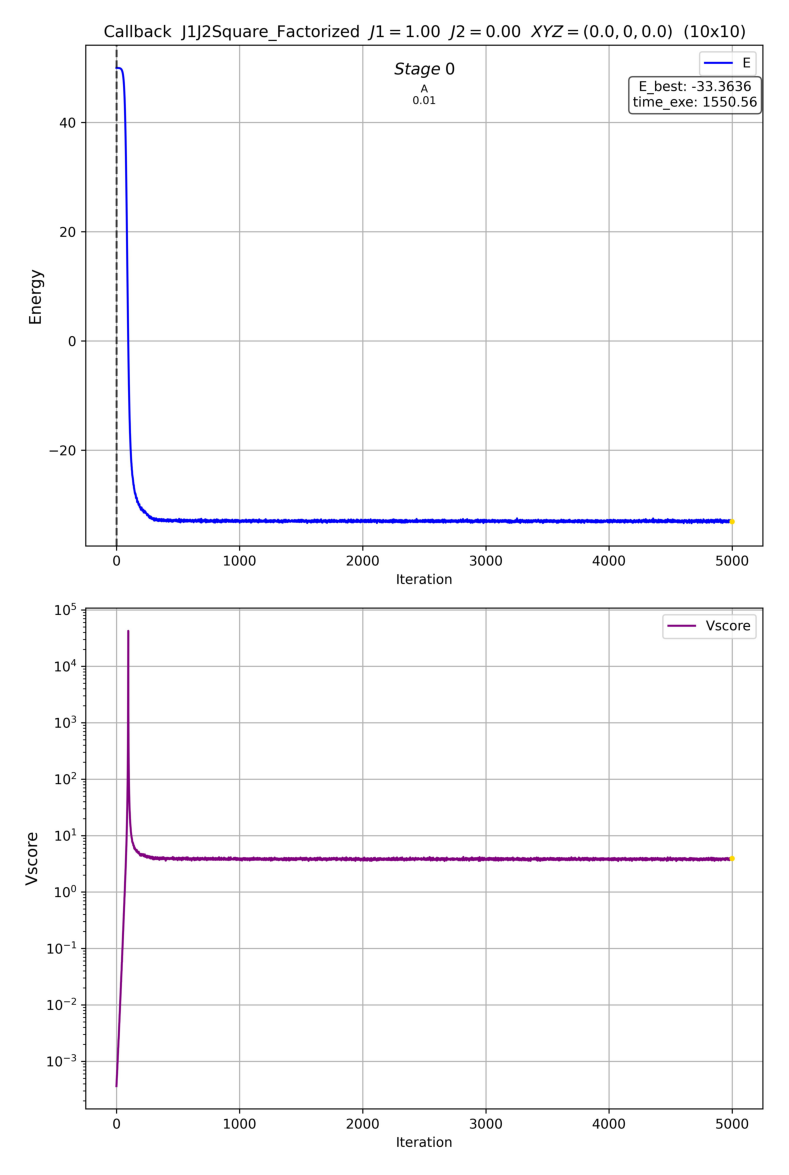



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_fee15c31/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260213T042954_UUID_fee15c31.json
{'Trans_0': {'phi': Array([ 8.23803557, -5.91617348,  6.07369294, -6.14289784,  5.89859283,
       -5.74979851,  8.29410737, -5.90840597,  6.48583333, -5.61925315,
       -5.87258236,  6.18852367, -6.06975068,  6.05642589, -6.10439647,
        6.10564503, -6.02191722,  6.05845644, -6.23242825,  5.8161509 ,
       -5.73247133, -5.84749835,  6.12530983, -6.06588874,  6.07646811,
       -6.08127254,  6.07686424, -6.00792696,  8.0026308 ,  6.00832152,
        5.89637618,  5.80316474, -6.13385705,  6.07071771, -6.07082061,
        6.06820729, -6.00330717,  8.07264196, -1.09503912, -8.05314465,
       -5.75502228, -7.13702492,  6.00327966, -6.07450861,  6.08939444,
       -6.02715647,  6.24408399, -5.33887796, -8.00667065,  6.05372885,
        7.2530533 , 

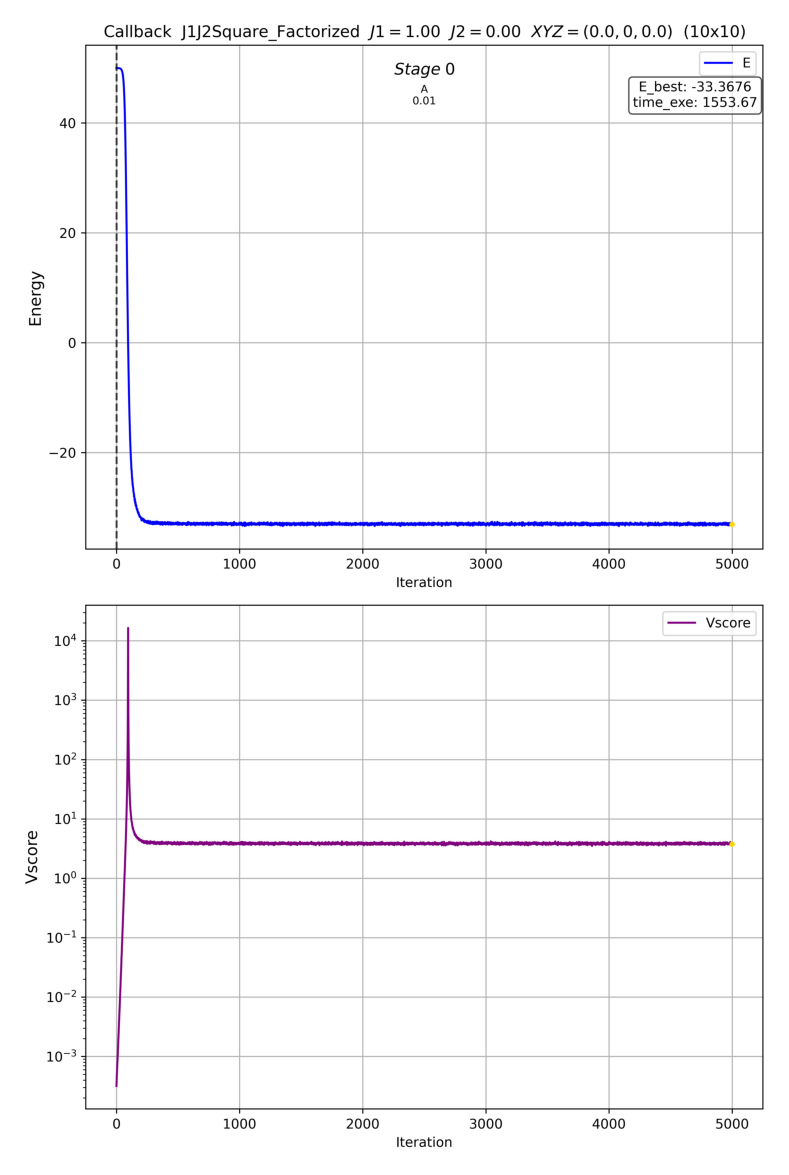



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_b1029772/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260212T230919_UUID_b1029772.json
{'Trans_0': {'phi': Array([ 8.21030667, -8.6428368 , -0.47127367,  8.24638276,  5.72420122,
       -6.06544845,  7.39280237,  5.65117324, -6.23372839,  5.63625317,
       -0.68430758,  8.187513  , -8.23378485,  5.66574309, -6.19570136,
        6.06494054, -5.91698653, -5.89890892,  6.04886576, -8.22260515,
       -8.1961964 , -5.69173852,  6.04372972, -6.1101035 ,  6.06265429,
       -6.09968553,  5.83497215,  5.93630423, -6.08667078,  5.94738908,
        5.76027693,  5.99234903, -6.07959869,  6.06537841, -6.08062605,
        5.98562654, -7.41670559, -5.75441253,  6.09335391, -6.11888437,
       -5.97894123, -5.79620184,  6.0961424 , -6.07745577,  6.02008642,
       -7.4692492 , -2.52596782,  7.50007576, -6.02390056,  6.08379533,
        5.68605937, 

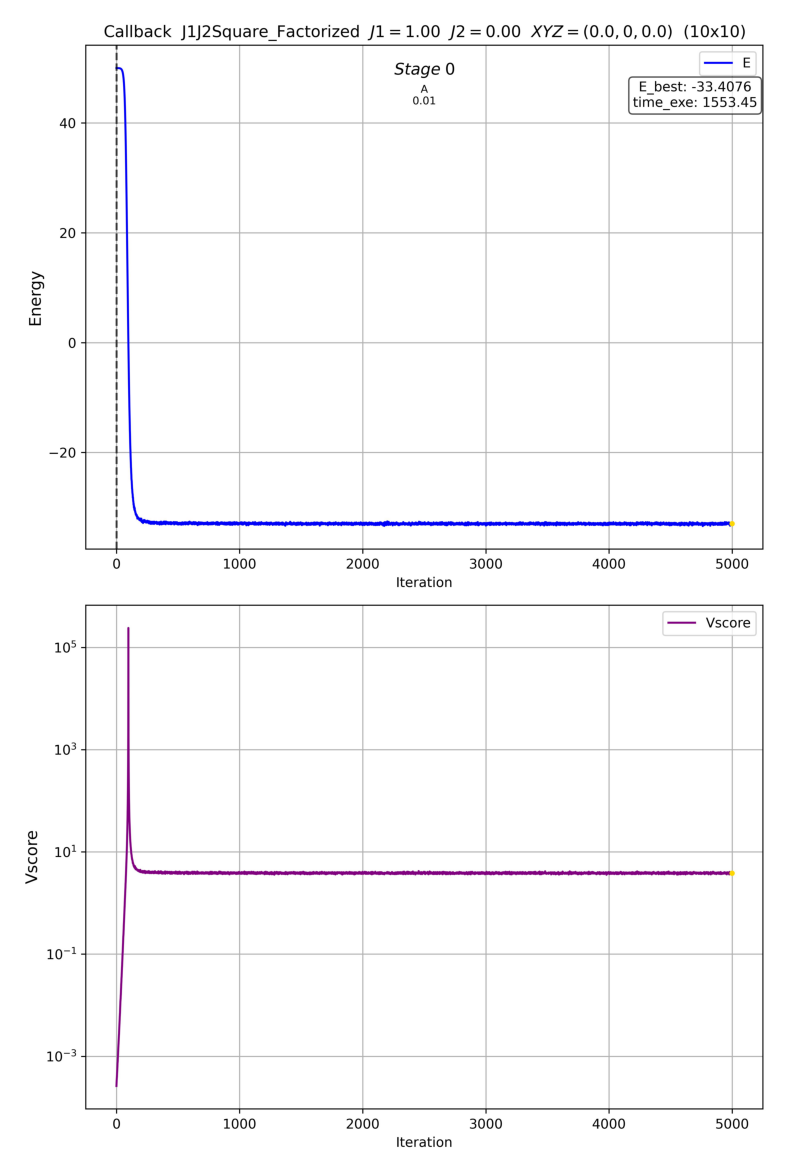



File: /home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/J1J2Square/Factorized_Transversal_Factorized/Size_10x10/ST_5000-0/UUID_bad069a5/J1J2Square_Factorized_results_10x10_J1J2_1.0_0.0_XYZ_0.0_0.0_0.0_date_20260212T200156_UUID_bad069a5.json
{'Trans_0': {'phi': Array([ 6.03797938, -6.17983343,  5.78281737, -5.71254694,  8.2864549 ,
       -5.9362153 ,  6.05893386, -6.15032159,  6.01205965, -6.09656472,
       -6.15559205,  5.61116417,  7.74425851, -8.24902614, -0.30870383,
        8.27652597, -5.9866    ,  5.62660702, -8.07686822,  5.92598352,
        5.86169753, -7.75473733, -1.64964793,  8.70111587, -8.26706767,
        5.72058512, -5.77888947,  8.08761037, -1.05540345, -8.77669155,
       -8.15661443,  8.01113954, -8.69421012, -0.09044373,  8.34364613,
       -6.04463644,  6.0586535 , -5.93054102,  8.7758505 ,  0.65530933,
       -7.9832336 , -0.99888234,  8.02465203, -8.33211132, -4.41251   ,
        6.24683647, -8.22904022,  5.97224276, -5.93212143,  8.17812505,
        6.00162133, 

In [5]:
import glob
from NN_module.saveNload import load_pytree
from NN_module.observables import distance_with_neel, distance_with_stripped
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import jax.numpy as jnp
size = (10,10)
neel = distance_with_neel(size)
stripped = distance_with_stripped(size)

parent = "/home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/"
paths_list = glob.glob(parent + "**/*_results_*.json", recursive=True)

for path in paths_list:

    with open(path, 'r') as f:
        artifact = json.load(f)

    param_path =artifact["_artifacts"]["parameters"]
    callback_path = artifact["_artifacts"]["callback"]["plot"]

    img = mpimg.imread(callback_path)
    plt.figure(figsize=(15,15))
    plt.imshow(img)
    plt.axis('off')  
    plt.show()

    parameters = load_pytree(param_path)
    print("\n")
    print(f"File: {path}")
    print(parameters)
    parameters = parameters['Trans_0']['phi'].reshape(size)
    filtered_params = jnp.where(parameters < 0, -1, 1)
    print(filtered_params) 

    dist_neel, neel_label = neel(filtered_params)
    dist_strip, strip_label = stripped(filtered_params)

    print("\n")
    print(f"Distance with Neel:     {dist_neel} ({neel_label})")
    print(f"Distance with Stripped: {dist_strip} ({strip_label})")

    print("\n")